In [2]:
!pip install opendatasets

In [3]:
import opendatasets as op
import os

if not os.path.exists("./covid19-radiography-database"):
  op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")
else:
  print("Датасет уже загружен!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mustafinilnur
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:07<00:00, 109MB/s]


Импорт библиотек

In [35]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import keras
from keras.preprocessing.image import  load_img                                       # загрузка изображений
from keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import random                                                                         # генератор случайных чисел
from sklearn.model_selection import train_test_split
import numpy as np                                                                    # библиотека линейной алгебры
import pandas as pd                                                                   # библиотека обработки табличных данных
import os                                                                             # библиотека работы с функциями операционной системы, в том числе с файлами
from albumentations import Compose, HorizontalFlip, RandomRotate90                                              # библиотека аугментации изображений (https://albumentations.ai/)

import matplotlib.pyplot as plt                                                       # библиотека для рисования графиков
%matplotlib inline

In [5]:
dataset_path = './covid19-radiography-database/COVID-19_Radiography_Dataset/Normal'
image_dir = 'images'
label_dir = 'masks'

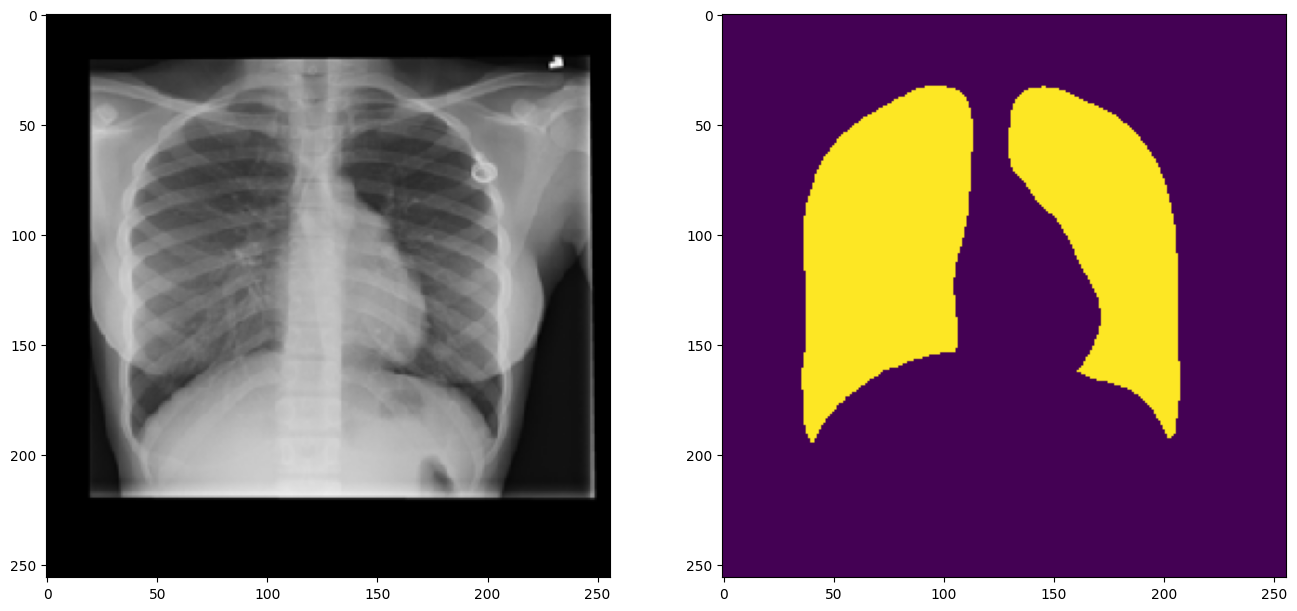

In [6]:
original_image = os.path.join(dataset_path, image_dir, 'Normal-1.png')       # путь до ориганального изображения
label_image_semantic = os.path.join(dataset_path, label_dir, 'Normal-1.png') # путь до маски

fig, axs = plt.subplots(1, 2, figsize=(16, 8))                          # задаем область для построения (канвас)

img = np.array(load_img(original_image, target_size=(256, 256), color_mode='rgb'))   # загружаем оригинальное изображение как RGB с 3 каналами
mask = np.array(load_img(label_image_semantic, target_size=(256, 256), color_mode='grayscale'))  # загружаем маску как "отеннки серого", т.е. в один канал

axs[0].imshow(img)  # отрисовываем оригинальное изображение
axs[0].grid(False)

axs[1].imshow(mask) # отрисовываем маску (одноканальное изображение, каждый класс отображается как отдельный цвет)
axs[1].grid(False)

In [7]:
input_img_path = sorted(
    [
        os.path.join(dataset_path, image_dir, fname)
        for fname in os.listdir(os.path.join(dataset_path, image_dir))
        if fname.endswith(".png")
    ]
)

target_img_path = sorted(
    [
        os.path.join(dataset_path, label_dir, fname)
        for fname in os.listdir(os.path.join(dataset_path, label_dir))
        if fname.endswith(".png")
    ]
)


NUM_CLASSES = 2
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [9]:
print("Количество изображений нормальных легких: ", len(input_img_path))
print("Количество масок нормальных легких: ", len(target_img_path))

Количество изображений нормальных легких:  10192
Количество масок нормальных легких:  10192


In [46]:
# Генератор для перебора данных (в виде массивов Numpy)

class datasetGenerator(keras.utils.Sequence):
    def __init__(self, batch_size, img_size, input_img_path, target_img_path=None,
                 num_classes=NUM_CLASSES, validation=False):
        self.batch_size = batch_size
        self.img_size = img_size
        self.input_img_path = input_img_path
        self.target_img_path = target_img_path
        self.validation = validation
        self.num_classes = num_classes

    def __len__(self):
        return len(self.target_img_path) // self.batch_size

    def __getitem__(self, idx):
        batch_input_img_path = self.input_img_path[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_target_img_path = self.target_img_path[idx*self.batch_size:(idx+1)*self.batch_size]

        x = np.zeros((self.batch_size, *self.img_size, 3), dtype="float32")
        y = np.zeros((self.batch_size, *self.img_size, self.num_classes), dtype="uint8")

        for i, (img_path, mask_path) in enumerate(zip(batch_input_img_path, batch_target_img_path)):
            img = np.array(load_img(img_path, target_size=self.img_size, color_mode='rgb'))
            mask = np.array(load_img(mask_path, target_size=self.img_size, color_mode='grayscale'))

            if not self.validation:
                transform = Compose([
                    HorizontalFlip(p=0.5),
                    RandomRotate90(p=0.5)
                ])
                transformed = transform(image=img, mask=mask)
                img = transformed["image"]
                mask = transformed["mask"]

            # Бинаризация маски
            mask_binary = (mask > 0).astype(np.uint8)

            x[i] = img / 255.0
            y[i] = to_categorical(mask_binary, num_classes=self.num_classes)

        return x, y


In [47]:
import random

seed = 1523
random.Random(seed).shuffle(input_img_path)
random.Random(seed).shuffle(target_img_path)

In [50]:
val_samples = round(len(input_img_path) * 0.2)

# Расщепим наш датасет  на обучающую и проверочные выборки
train_input_img_path = input_img_path[:-val_samples]
train_target_img_path = target_img_path[:-val_samples]
val_input_img_path = input_img_path[-val_samples:]
val_target_img_path = target_img_path[-val_samples:]

In [51]:
batch_size = 32
img_size = IMG_SIZE
num_classes = NUM_CLASSES
train_gen = datasetGenerator(batch_size, img_size, train_input_img_path, train_target_img_path, num_classes)

val_gen = datasetGenerator(batch_size, img_size, val_input_img_path, val_target_img_path, num_classes, validation = True)

In [53]:
from tensorflow.keras import regularizers

def convolution_operation(entered_input, filters=64, dropout_rate=0.1):
    conv1 = Conv2D(filters, kernel_size=(3,3), padding="same",
                   kernel_regularizer=regularizers.l2(1e-4))(entered_input)
    batch_norm1 = BatchNormalization()(conv1)
    acti1 = ReLU()(batch_norm1)
    dropout1 = Dropout(dropout_rate)(acti1)  # Добавляем Dropout

    conv2 = Conv2D(filters, kernel_size=(3,3), padding="same",
                   kernel_regularizer=regularizers.l2(1e-4))(dropout1)
    batch_norm2 = BatchNormalization()(conv2)
    acti2 = ReLU()(batch_norm2)

    return acti2

In [54]:
# Функция кодировщика
# На входе 2 параметра - предыдущий слой и число фильтров (генерируемых карт признаков)
def encoder(entered_input, filters=64):

    encod1 = convolution_operation(entered_input, filters)  # функция свертки - 2 синих блока
    MaxPool1 = MaxPooling2D(strides = (2,2))(encod1)        # зеленый блок
    return encod1, MaxPool1 # функция возвращает латеральное соединение и выход из слоя

# Функция декодировщика
# На входе 3 параметра - предыдущий слой и латеральное соединение и число фильтров (генерируемых карт признаков)
def decoder(entered_input, skip, filters=64):
    Upsample = Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(entered_input) # красный блок
    Connect_Skip = Concatenate()([Upsample, skip])                                        # белый блок (объединение латерального соединения и выхода предыдущего слоя)
    out = convolution_operation(Connect_Skip, filters)                                    # функция свертки - 2 синих блока
    return out # функция возвращает выход из слоя

Соберем сеть целиком.

In [55]:
# Наша интерпретация модели U-net
def U_Net(img_size, num_classes):
    # Входной слой - желтый блок
    inputs = Input(img_size)

    # Задаем блоки кодировщика и латеральные соединения
    skip1, encoder_1 = encoder(inputs, 64)
    skip2, encoder_2 = encoder(encoder_1, 64*2)
    skip3, encoder_3 = encoder(encoder_2, 64*4)
    skip4, encoder_4 = encoder(encoder_3, 64*8)

    # Бутылочное горлышка задаем 2-мя синими блоками
    conv_block = convolution_operation(encoder_4, 64*16)

    # Задаем блоки декодировщика и передаем ему латеральные соединения от кодировщиков
    decoder_1 = decoder(conv_block, skip4, 64*8)
    decoder_2 = decoder(decoder_1, skip3, 64*4)
    decoder_3 = decoder(decoder_2, skip2, 64*2)
    decoder_4 = decoder(decoder_3, skip1, 64)

    # Выходной слой (фиолетовый блок), его конфигурация зависит от решаемой задачи
    outputs = Conv2D(num_classes, kernel_size = (1, 1), padding="same", activation="softmax")(decoder_4)

    model = Model(inputs, outputs)
    return model

In [18]:
num_classes = NUM_CLASSES # 24 класса объектов
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3) # размер к которому преобразуем изображение, 3 канала - RGB
model = U_Net(input_shape, num_classes) # инициализируем модель

In [60]:
model.compile(
    optimizer='adam' ,
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_segmentation.keras",
                                   monitor='accuracy',
                                   save_best_only=True,
                                   mode='max'),
    keras.callbacks.EarlyStopping(monitor='val_loss',
                                 patience=3,
                                 restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                     factor=0.5,
                                     patience=3,
                                     min_lr=1e-7),
]

In [62]:
model.summary() # отчет о структуре модели

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 93,142,536 (355.31 MB)

 Trainable params: 31,043,586 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

 Optimizer params: 62,087,174 (236.84 MB)

In [61]:
epochs = 15
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=callbacks
                   )

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 162s 555ms/step - accuracy: 0.9919 - loss: 0.0207 - val_accuracy: 0.9220 - val_loss: 0.8065 - learning_rate: 0.0010
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 126s 494ms/step - accuracy: 0.9900 - loss: 0.0255 - val_accuracy: 0.9938 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 146s 574ms/step - accuracy: 0.9935 - loss: 0.0157 - val_accuracy: 0.9940 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 132s 520ms/step - accuracy: 0.9937 - loss: 0.0156 - val_accuracy: 0.9941 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 125s 490ms/step - accuracy: 0.9935 - loss: 0.0169 - val_accuracy: 0.9938 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 133s 522ms/step - accuracy: 0.9946 - loss: 0.0131 - val_accuracy: 0.9938 - val_loss: 0.0149 - learning_rate: 0.0010


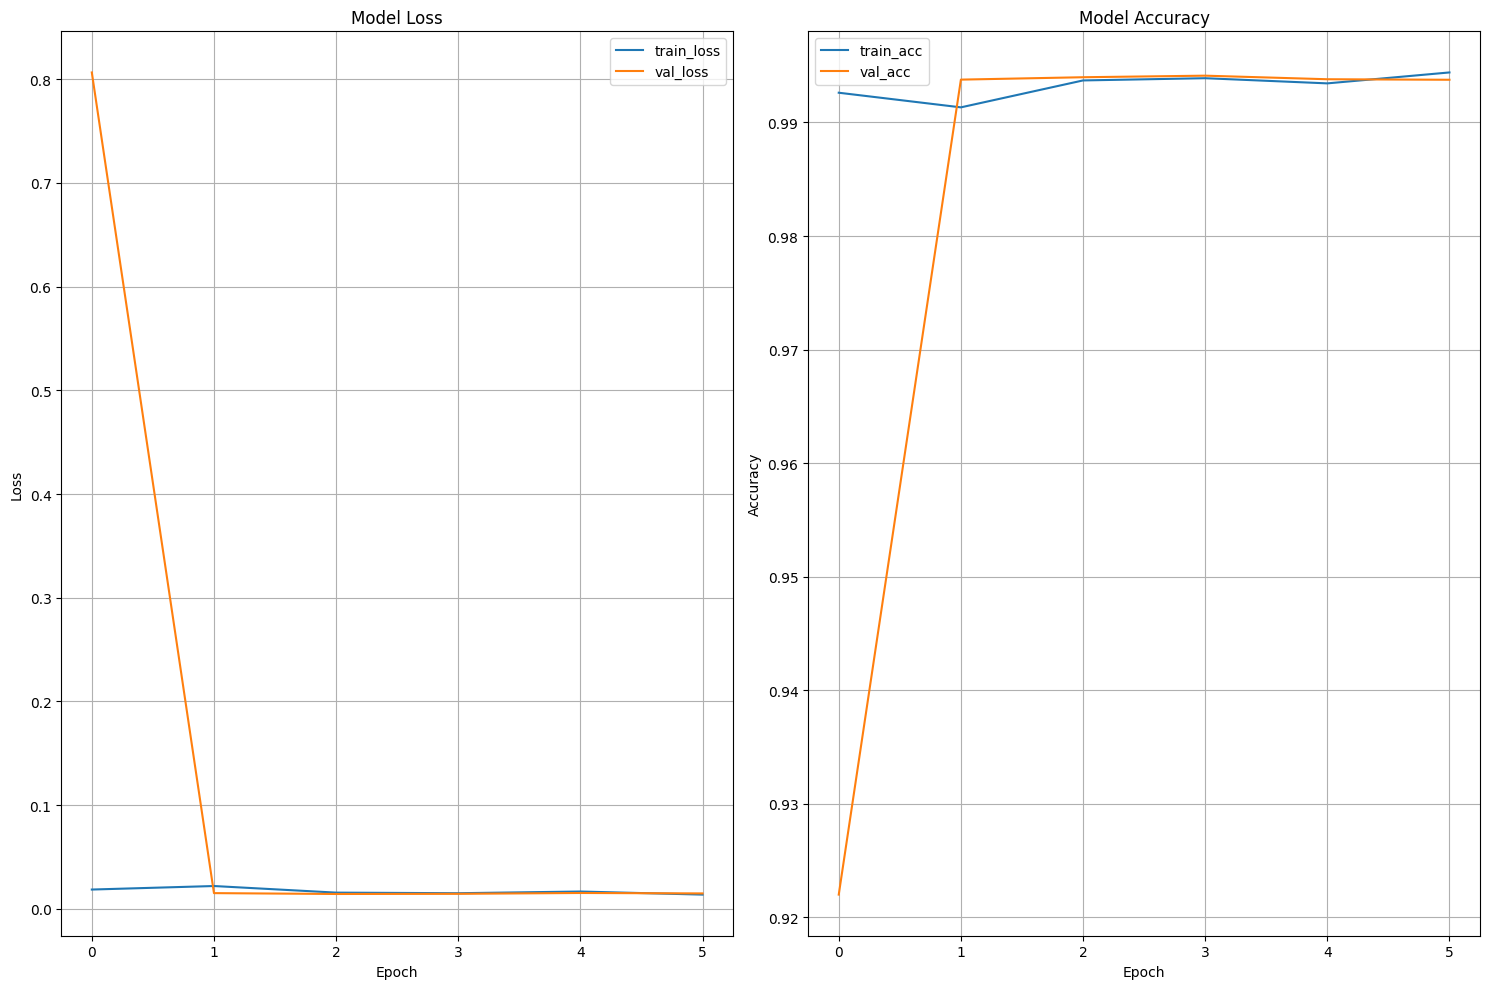

In [67]:
# После обучения
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 10))

    # Loss
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


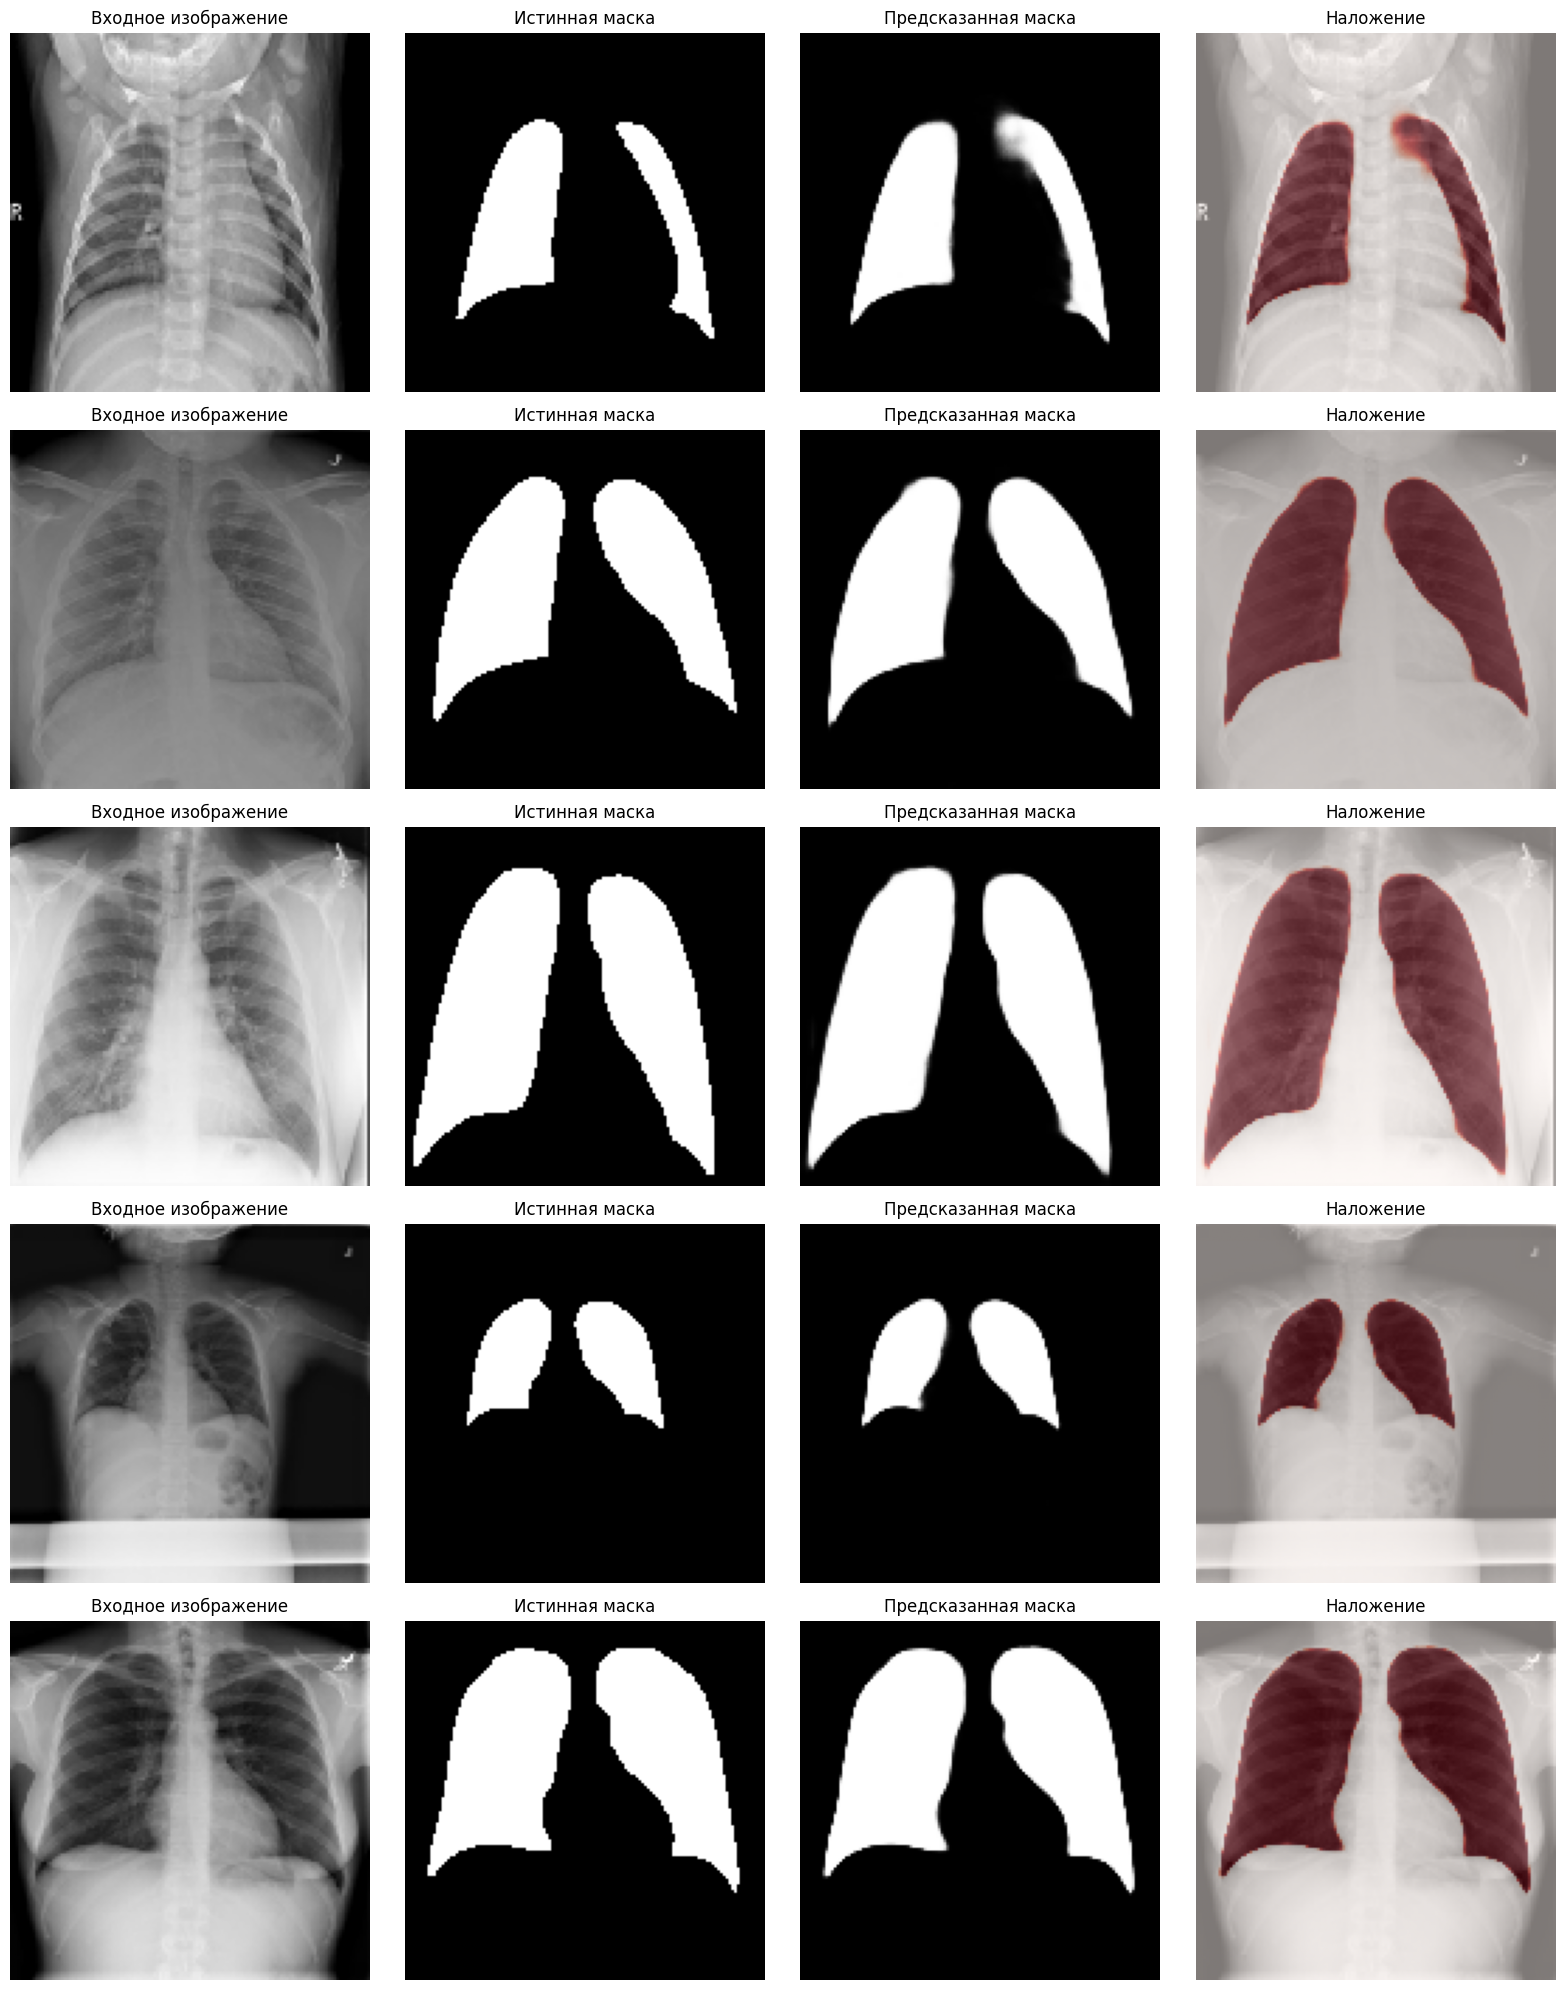

In [69]:
def visualize_predictions(model, generator, num_samples=5):
    # Получаем батч данных
    x_val, y_val = generator[0]

    # Предсказания
    y_pred = model.predict(x_val[:num_samples])

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    # Если только один образец, axes будет 1D массивом
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # Исходное изображение
        axes[i, 0].imshow(x_val[i])
        axes[i, 0].set_title('Входное изображение')
        axes[i, 0].axis('off')

        # Истинная маска
        axes[i, 1].imshow(y_val[i, :, :, 1], cmap='gray')
        axes[i, 1].set_title('Истинная маска')
        axes[i, 1].axis('off')

        # Предсказанная маска
        axes[i, 2].imshow(y_pred[i, :, :, 1], cmap='gray')
        axes[i, 2].set_title('Предсказанная маска')
        axes[i, 2].axis('off')

        # Наложение
        axes[i, 3].imshow(x_val[i])
        axes[i, 3].imshow(y_pred[i, :, :, 1], alpha=0.5, cmap='Reds')
        axes[i, 3].set_title('Наложение')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Визуализируем результаты
visualize_predictions(model, val_gen)